# EDA и моделирование по данным электроэнергии РФ

Ноутбук собирает единую панель по регионам РФ, проводит исследовательский анализ данных и сравнивает несколько моделей для задачи краткосрочного прогнозирования цены покупки электроэнергии.

## Что есть в ноутбуке

- построение панели из почасовых, суточных и месячных файлов;
- EDA по распределению цены, сезонности, регионам и пропускам;
- сравнение baseline, линейных, tree-based и `KAN`-подобных моделей;
- абляция признаков;
- диагностика ошибок лучшей полной `KAN`-модели;
- готовые выводы, которые можно использовать в ВКР.

In [1]:
from pathlib import Path
import glob
import json
import os

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
np.random.seed(42)

ROOT = Path.cwd()
DATA_DIR = ROOT / 'Данные электроэнергии'
OUT_DIR = ROOT / 'analysis_outputs'
OUT_DIR.mkdir(exist_ok=True)

## Вспомогательные функции

In [2]:
def region_name(path: Path, suffix: str) -> str:
    name = path.name
    return name[len('region_') : -len(suffix)]


def to_num(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    value = str(value).strip().replace(' ', '').replace(' ', '')
    if value in {'', '-', '—'}:
        return np.nan
    value = value.replace(',', '.')
    try:
        return float(value)
    except ValueError:
        return np.nan


def discover_region_files():
    hourly_dir = DATA_DIR / 'торги и перетоки почасовые'
    daily_dir = DATA_DIR / 'посуточные'
    monthly_dir = DATA_DIR / 'ставки, стоимость, отчет - месяц'

    hourly = {region_name(Path(p), '_data.csv'): Path(p) for p in glob.glob(str(hourly_dir / 'region_*_data.csv'))}
    daily = {region_name(Path(p), '_day.csv'): Path(p) for p in glob.glob(str(daily_dir / 'region_*_day.csv'))}
    monthly = {region_name(Path(p), '_mon.csv'): Path(p) for p in glob.glob(str(monthly_dir / 'region_*_mon.csv'))}
    common_regions = sorted(set(hourly) & set(daily) & set(monthly))
    return hourly, daily, monthly, common_regions

In [3]:
def build_panel_dataset():
    hourly, daily, monthly, regions = discover_region_files()

    monthly_cols = {
        'Стоимость услуги по оперативно-диспетчерскому управлению в электроэнергетике, оказанной АО "СО ЕЭС", приходящаяся на ГТП потребления с признаком гарантирующего поставщика': 'so_service_cost',
        'Стоимость комплексной услуги АО «ЦФР», приходящаяся на ГТП потребления с признаком гарантирующего поставщика': 'cfr_service_cost',
        'P_субъект_РФ, Совокупная нерегулируемая часть объема фактического пикового потребления в субъекте Российской Федерации, МВт': 'peak_demand_mw',
        'Стоимость электрической энергии и мощности для целей определения ставки тарифа на услуги по передаче электрической энергии, используемой для целей определения расходов на оплату нормативных потерь электрической энергии при ее передаче по электрическим сетям единой национальной (общероссийской) электрической сети': 'energy_power_cost',
        'Объем потерь электрической энергии в электрических сетях единой национальной (общероссийской) электрической сети ': 'grid_losses_volume',
        'Ставка тарифа на услуги по передаче электрической энергии, используемая для целей определения расходов на оплату нормативных потерь электрической энергии при ее передаче по электрическим сетям единой национальной (общероссийской) электрической сети': 'grid_loss_tariff_rate',
    }

    base_rename = {
        'Плановый объём потребления, МВт.ч._first': 'planned_consumption_mwh',
        'Плановый объём экспорта, МВт.ч._first': 'planned_export_mwh',
        'Плановый объём импорта, МВт.ч._first': 'planned_import_mwh',
        'Средневзвешенная цена на покупку электроэнергии, руб./МВт.ч._first': 'purchase_price_rub_mwh',
        'Средневзвешенная цена на продажу электроэнергии, руб./МВт.ч._first': 'sale_price_rub_mwh',
        'Полный плановый объем потребления, МВт.ч._first': 'full_planned_consumption_mwh',
        'Субъект РФ - Получатель_nunique': 'recipient_count',
        'Объём перетока_sum': 'total_outflow',
        'Объём перетока_mean': 'mean_outflow',
        'Объём перетока_max': 'max_outflow',
        'Объем потерь, МВтЧ.': 'daily_losses_mwh',
    }

    hourly_keep = [
        'ГЭС', 'АЭС', 'ТЭС', 'СЭС', 'ВЭС',
        'ГЭС.1', 'АЭС.1', 'ТЭС.1', 'СЭС.1', 'ВЭС.1',
        'ГЭС.2', 'АЭС.2', 'ТЭС.2', 'СЭС.2', 'ВЭС.2',
        'ГЭС.3', 'АЭС.3', 'ТЭС.3', 'СЭС.3', 'ВЭС.3',
        'Плановый объём потребления, МВт.ч.', 'Плановый объём экспорта, МВт.ч.',
        'Плановый объём импорта, МВт.ч.', 'Средневзвешенная цена на покупку электроэнергии, руб./МВт.ч.',
        'Средневзвешенная цена на продажу электроэнергии, руб./МВт.ч.', 'Полный плановый объем потребления, МВт.ч.'
    ]

    frames = []
    daily_min, daily_max, month_min, month_max = [], [], [], []

    for region in regions:
        h = pd.read_csv(hourly[region])
        h['Дата'] = pd.to_datetime(h['Дата'])
        agg_spec = {col: 'first' for col in hourly_keep if col in h.columns}
        agg_spec['Субъект РФ - Получатель'] = 'nunique'
        agg_spec['Объём перетока'] = ['sum', 'mean', 'max']
        g = h.groupby(['Субъект РФ', 'Дата', 'Час']).agg(agg_spec)
        g.columns = ['_'.join([x for x in col if x]).strip('_') for col in g.columns]
        g = g.reset_index().rename(columns=base_rename)

        d = pd.read_csv(daily[region])
        d['Дата'] = pd.to_datetime(d['Дата'])
        d = d[['Дата', 'Объем потерь, МВтЧ.']].rename(columns=base_rename)
        daily_min.append(d['Дата'].min())
        daily_max.append(d['Дата'].max())

        m = pd.read_csv(monthly[region])
        for src, dst in monthly_cols.items():
            if src in m.columns:
                m[dst] = m[src].map(to_num)
        m['month'] = pd.to_datetime(m['Дата_x'], dayfirst=True, errors='coerce').dt.to_period('M').dt.to_timestamp()
        month_min.append(m['month'].min())
        month_max.append(m['month'].max())
        m_agg = (
            m.groupby('month')
            .agg({
                'so_service_cost': 'sum',
                'cfr_service_cost': 'sum',
                'peak_demand_mw': 'max',
                'energy_power_cost': 'max',
                'grid_losses_volume': 'max',
                'grid_loss_tariff_rate': 'max',
            })
            .reset_index()
        )

        g['month'] = g['Дата'].dt.to_period('M').dt.to_timestamp()
        out = g.merge(d, on='Дата', how='left').merge(m_agg, on='month', how='left')
        out['region'] = region
        frames.append(out)

    panel = pd.concat(frames, ignore_index=True)
    panel['datetime'] = pd.to_datetime(panel['Дата']) + pd.to_timedelta(panel['Час'], unit='h')

    common_start = max(min(daily_min), min(month_min))
    common_end = min(max(daily_max), max(month_max) + pd.offsets.MonthEnd(0))
    panel = panel[(panel['Дата'] >= common_start) & (panel['Дата'] <= common_end)].copy()
    panel = panel.sort_values(['region', 'datetime']).reset_index(drop=True)

    for lag in [1, 24, 168]:
        panel[f'price_lag_{lag}'] = panel.groupby('region')['purchase_price_rub_mwh'].shift(lag)
        panel[f'cons_lag_{lag}'] = panel.groupby('region')['planned_consumption_mwh'].shift(lag)

    panel['hour'] = panel['datetime'].dt.hour
    panel['dayofweek'] = panel['datetime'].dt.dayofweek
    panel['month_num'] = panel['datetime'].dt.month
    panel['is_weekend'] = (panel['dayofweek'] >= 5).astype(int)
    panel['sin_hour'] = np.sin(2 * np.pi * panel['hour'] / 24)
    panel['cos_hour'] = np.cos(2 * np.pi * panel['hour'] / 24)
    panel['sin_dow'] = np.sin(2 * np.pi * panel['dayofweek'] / 7)
    panel['cos_dow'] = np.cos(2 * np.pi * panel['dayofweek'] / 7)

    panel = panel.dropna(subset=['purchase_price_rub_mwh', 'price_lag_168', 'cons_lag_168']).copy()
    panel = panel.drop(columns=[col for col in panel.columns if panel[col].isna().mean() == 1.0])
    return panel

In [4]:
panel_path = OUT_DIR / 'russian_electricity_panel_dataset.csv'
if panel_path.exists():
    panel = pd.read_csv(panel_path, parse_dates=['Дата', 'datetime', 'month'])
else:
    panel = build_panel_dataset()
    panel.to_csv(panel_path, index=False)

print(panel.shape)
panel.head()

(99312, 57)


,Субъект РФ,Дата,Час,ГЭС_first,АЭС_first,ТЭС_first,СЭС_first,ВЭС_first,ГЭС.1_first,АЭС.1_first,ТЭС.1_first,СЭС.1_first,ВЭС.1_first,ГЭС.2_first,АЭС.2_first,ТЭС.2_first,СЭС.2_first,ВЭС.2_first,ГЭС.3_first,АЭС.3_first,ТЭС.3_first,СЭС.3_first,ВЭС.3_first,planned_consumption_mwh,planned_export_mwh,planned_import_mwh,purchase_price_rub_mwh,sale_price_rub_mwh,full_planned_consumption_mwh,recipient_count,total_outflow,mean_outflow,max_outflow,month,daily_losses_mwh,so_service_cost,cfr_service_cost,peak_demand_mw,energy_power_cost,grid_losses_volume,grid_loss_tariff_rate,region,datetime,price_lag_1,cons_lag_1,price_lag_24,cons_lag_24,price_lag_168,cons_lag_168,hour,dayofweek,month_num,is_weekend,sin_hour,cos_hour,sin_dow,cos_dow
0,Новгородская область,2023-08-30,0,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,413.967,176.550,536.120,1387.01,1380.61,424.467,3,176.549928,58.849976,100.453327,2023-08-01,138.16,67789.33,259575.99,375.016,20889812.21,9250.12,2258.33,Новгородская область,2023-08-30 00:00:00,1368.87,431.630,1200.69,406.800,1138.96,395.727,0,2,8,0,0.000000,1.000000,0.974928,-0.222521
1,Новгородская область,2023-08-30,1,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,406.305,208.509,561.352,1259.25,1253.07,416.805,3,208.509088,69.503029,106.198989,2023-08-01,138.16,67789.33,259575.99,375.016,20889812.21,9250.12,2258.33,Новгородская область,2023-08-30 01:00:00,1387.01,413.967,1074.70,399.406,870.52,388.040,1,2,8,0,0.258819,0.965926,0.974928,-0.222521
2,Новгородская область,2023-08-30,2,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,401.309,210.935,558.710,1209.03,1203.07,411.809,3,210.935189,70.311730,106.941781,2023-08-01,138.16,67789.33,259575.99,375.016,20889812.21,9250.12,2258.33,Новгородская область,2023-08-30 02:00:00,1259.25,406.305,968.85,400.593,805.89,386.418,2,2,8,0,0.500000,0.866025,0.974928,-0.222521
3,Новгородская область,2023-08-30,3,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,401.824,209.645,557.935,1201.40,1195.47,412.324,3,209.644578,69.881526,106.309931,2023-08-01,138.16,67789.33,259575.99,375.016,20889812.21,9250.12,2258.33,Новгородская область,2023-08-30 03:00:00,1209.03,401.309,969.29,397.341,523.12,386.060,3,2,8,0,0.707107,0.707107,0.974928,-0.222521
4,Новгородская область,2023-08-30,4,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,402.829,226.898,576.874,1205.85,1199.79,413.329,3,226.898070,75.632690,113.635604,2023-08-01,138.16,67789.33,259575.99,375.016,20889812.21,9250.12,2258.33,Новгородская область,2023-08-30 04:00:00,1201.40,401.824,1035.56,399.142,521.40,384.335,4,2,8,0,0.866025,0.500000,0.974928,-0.222521


## Быстрая сводка по данным

In [5]:
summary = {
    'rows': int(len(panel)),
    'columns': int(panel.shape[1]),
    'regions': int(panel['region'].nunique()),
    'datetime_min': str(panel['datetime'].min()),
    'datetime_max': str(panel['datetime'].max()),
    'target_mean': round(float(panel['purchase_price_rub_mwh'].mean()), 3),
    'target_std': round(float(panel['purchase_price_rub_mwh'].std()), 3),
    'target_zero_share_pct': round(float((panel['purchase_price_rub_mwh'] == 0).mean() * 100), 3),
}
summary

{'rows': 99312,
 'columns': 57,
 'regions': 34,
 'datetime_min': '2023-08-30 00:00:00',
 'datetime_max': '2023-12-31 23:00:00',
 'target_mean': 1602.36,
 'target_std': 439.564,
 'target_zero_share_pct': 0.039}

## EDA: пропуски, распределение цены и сезонность

In [6]:
missing = (panel.isna().mean() * 100).sort_values(ascending=False)
missing.head(20)

ВЭС.1_first    85.016916
ВЭС.3_first    85.016916
ВЭС_first      85.016916
ВЭС.2_first    85.016916
АЭС_first      82.020300
АЭС.1_first    82.020300
АЭС.3_first    82.020300
АЭС.2_first    82.020300
СЭС.2_first    71.749638
СЭС.3_first    71.749638
СЭС_first      71.749638
СЭС.1_first    71.749638
ГЭС_first      64.040599
ГЭС.1_first    64.040599
ГЭС.3_first    64.040599
ГЭС.2_first    64.040599
ТЭС.3_first     4.277429
ТЭС.2_first     4.277429
ТЭС.1_first     4.277429
ТЭС_first       4.277429
dtype: float64

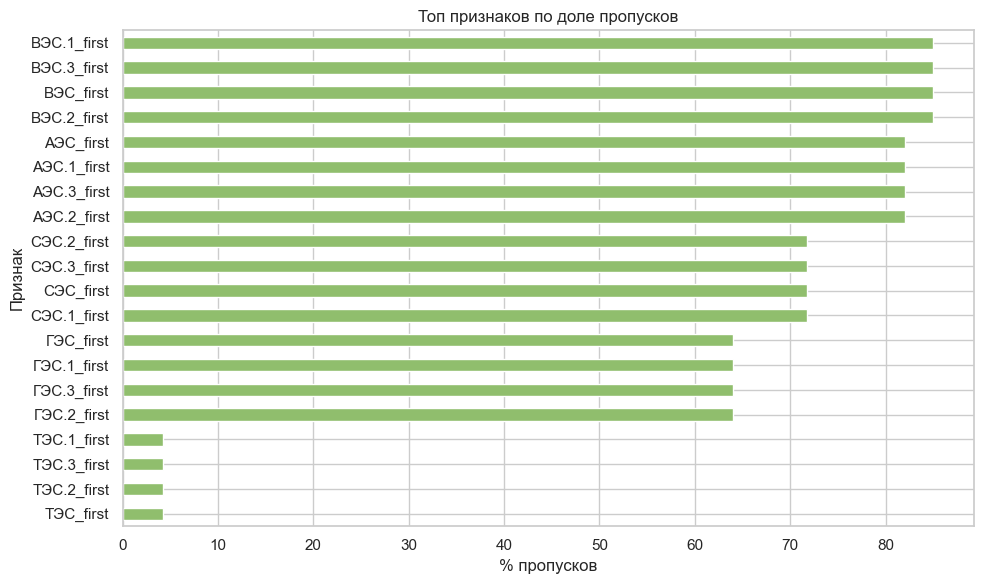

In [7]:
plt.figure(figsize=(10, 6))
missing.head(20).sort_values().plot(kind='barh', color='#90be6d')
plt.title('Топ признаков по доле пропусков')
plt.xlabel('% пропусков')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [8]:
panel['purchase_price_rub_mwh'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    99312.000000
mean      1602.359514
std        439.563866
min          0.000000
1%         700.970600
5%         978.231000
50%       1609.860000
95%       2317.069000
99%       2620.630200
max       4706.610000
Name: purchase_price_rub_mwh, dtype: float64

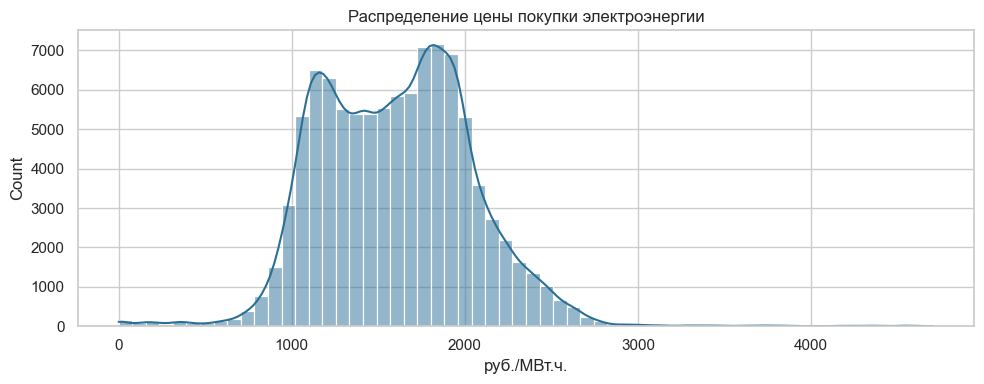

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(panel['purchase_price_rub_mwh'], bins=60, kde=True, color='#2a6f97')
plt.title('Распределение цены покупки электроэнергии')
plt.xlabel('руб./МВт.ч.')
plt.tight_layout()
plt.show()

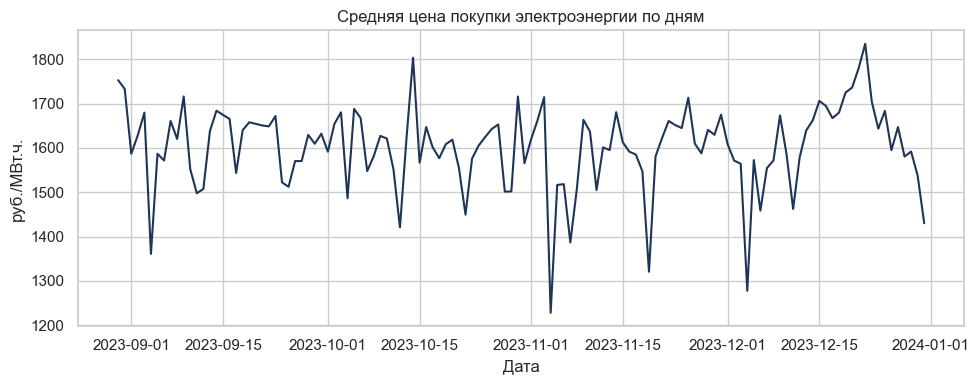

In [10]:
plt.figure(figsize=(10, 4))
panel.groupby(panel['datetime'].dt.date)['purchase_price_rub_mwh'].mean().plot(color='#1d3557')
plt.title('Средняя цена покупки электроэнергии по дням')
plt.xlabel('Дата')
plt.ylabel('руб./МВт.ч.')
plt.tight_layout()
plt.show()

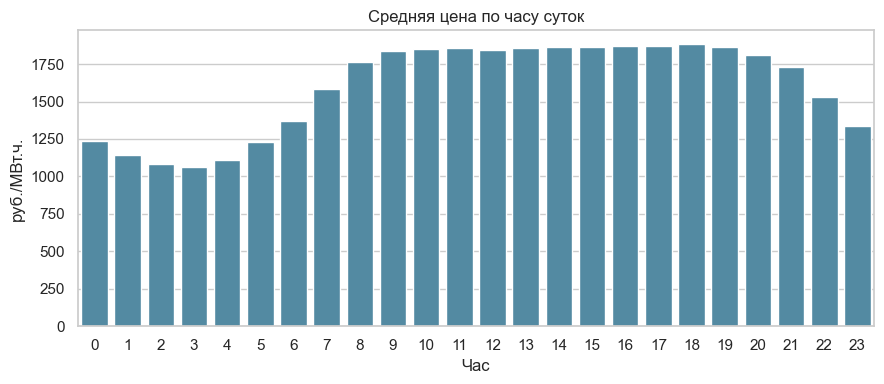

(hour
 18    1881.15
 17    1871.54
 16    1868.53
 19    1867.00
 15    1864.50
 Name: purchase_price_rub_mwh, dtype: float64,
 hour
 3    1064.78
 2    1080.76
 4    1107.96
 1    1146.17
 5    1230.04
 Name: purchase_price_rub_mwh, dtype: float64)

In [11]:
hour_price = panel.groupby('hour')['purchase_price_rub_mwh'].mean().round(2)
plt.figure(figsize=(9, 4))
sns.barplot(x=hour_price.index, y=hour_price.values, color='#468faf')
plt.title('Средняя цена по часу суток')
plt.xlabel('Час')
plt.ylabel('руб./МВт.ч.')
plt.tight_layout()
plt.show()

hour_price.sort_values(ascending=False).head(5), hour_price.sort_values().head(5)

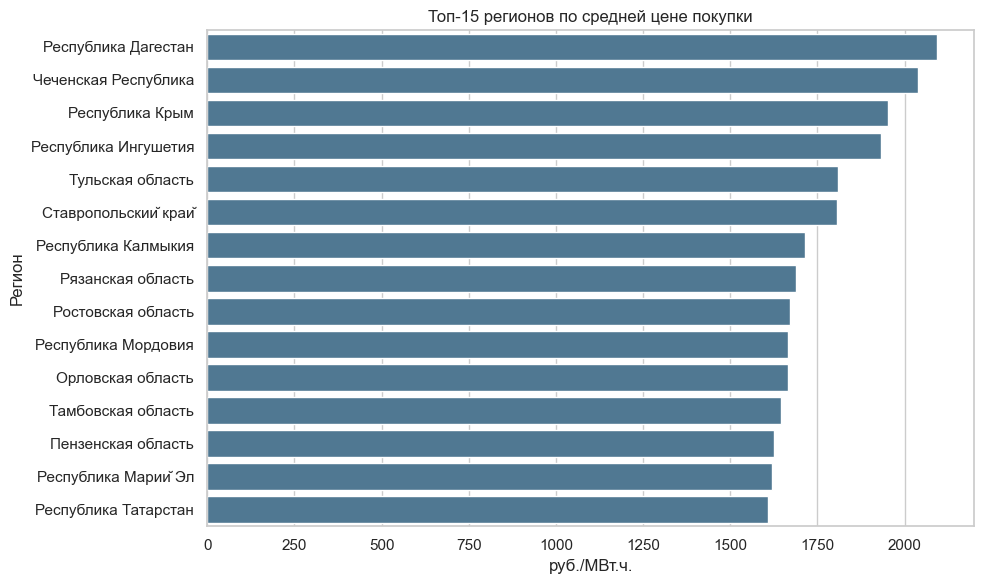

region
Республика Дагестан      2094.157470
Чеченская Республика     2037.887194
Республика Крым          1951.474110
Республика Ингушетия     1930.926583
Тульская область         1809.614829
Ставропольский край    1806.740084
Республика Калмыкия      1715.573219
Рязанская область        1689.343427
Ростовская область       1671.009651
Республика Мордовия      1666.624580
Орловская область        1666.265874
Тамбовская область       1644.079459
Пензенская область       1624.428256
Республика Марий Эл     1620.199889
Республика Татарстан     1606.851764
Name: purchase_price_rub_mwh, dtype: float64

In [12]:
region_price = panel.groupby('region')['purchase_price_rub_mwh'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(y=region_price.head(15).index, x=region_price.head(15).values, color='#457b9d')
plt.title('Топ-15 регионов по средней цене покупки')
plt.xlabel('руб./МВт.ч.')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()

region_price.head(15)

## Корреляции и аргумент в пользу KAN

In [13]:
key_corr = {
    'corr_price_lag_1': round(panel['purchase_price_rub_mwh'].corr(panel['price_lag_1']), 3),
    'corr_price_lag_24': round(panel['purchase_price_rub_mwh'].corr(panel['price_lag_24']), 3),
    'corr_consumption': round(panel['purchase_price_rub_mwh'].corr(panel['planned_consumption_mwh']), 3),
    'corr_total_outflow': round(panel['purchase_price_rub_mwh'].corr(panel['total_outflow']), 3),
}
key_corr

{'corr_price_lag_1': 0.939,
 'corr_price_lag_24': 0.848,
 'corr_consumption': -0.115,
 'corr_total_outflow': -0.055}

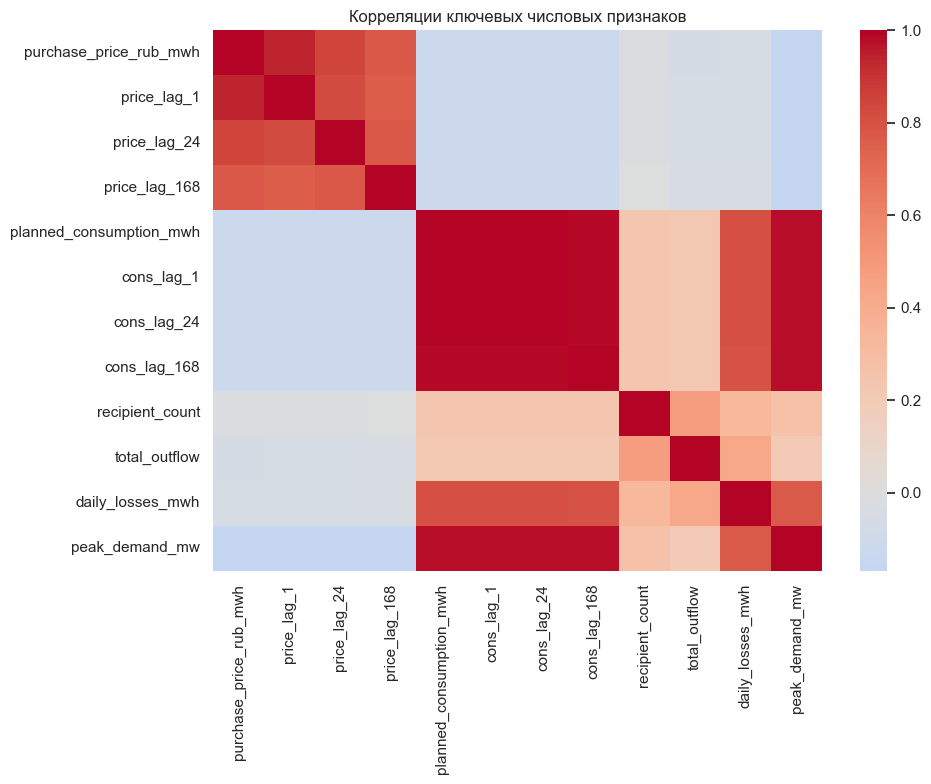

In [14]:
corr_cols = [
    'purchase_price_rub_mwh', 'price_lag_1', 'price_lag_24', 'price_lag_168',
    'planned_consumption_mwh', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168',
    'recipient_count', 'total_outflow', 'daily_losses_mwh', 'peak_demand_mw'
]

corr_df = panel[[c for c in corr_cols if c in panel.columns]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap='coolwarm', center=0)
plt.title('Корреляции ключевых числовых признаков')
plt.tight_layout()
plt.show()

### Почему данные подходят для `KAN`

- есть выраженная инерционность и сезонность цены;
- данные содержат несколько источников нелинейности: нагрузка, перетоки, потери, месячные стоимостные факторы;
- задача имеет смешанную структуру признаков: лаги, календарь, регион, инфраструктурные и стоимостные показатели;
- поэтому здесь разумно сравнивать не только классические линейные модели, но и гибридные `KAN`-подходы.

## Подготовка выборок и признаков

In [15]:
train = panel[panel['datetime'] < '2023-11-01'].copy()
val = panel[(panel['datetime'] >= '2023-11-01') & (panel['datetime'] < '2023-12-01')].copy()
test = panel[panel['datetime'] >= '2023-12-01'].copy()

print(train.shape, val.shape, test.shape)

(50616, 57) (24000, 57) (24696, 57)


In [16]:
sparse_generation_cols = [
    'ГЭС_first', 'АЭС_first', 'СЭС_first', 'ВЭС_first',
    'ГЭС.1_first', 'АЭС.1_first', 'СЭС.1_first', 'ВЭС.1_first',
    'ГЭС.2_first', 'АЭС.2_first', 'СЭС.2_first', 'ВЭС.2_first',
    'ГЭС.3_first', 'АЭС.3_first', 'СЭС.3_first', 'ВЭС.3_first',
]
dense_generation_cols = ['ТЭС_first', 'ТЭС.1_first', 'ТЭС.2_first', 'ТЭС.3_first']

for col in sparse_generation_cols + dense_generation_cols:
    if col in panel.columns:
        train[col] = train[col].fillna(0.0)
        val[col] = val[col].fillna(0.0)
        test[col] = test[col].fillna(0.0)

feature_sets = {
    'lags_only': ['region', 'price_lag_1', 'price_lag_24', 'price_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168'],
    'lags_calendar': ['region', 'price_lag_1', 'price_lag_24', 'price_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'hour', 'dayofweek', 'month_num', 'is_weekend', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow'],
    'lags_calendar_flows': ['region', 'price_lag_1', 'price_lag_24', 'price_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'hour', 'dayofweek', 'month_num', 'is_weekend', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'recipient_count', 'total_outflow', 'daily_losses_mwh'],
    'full': ['region', 'Час', 'planned_consumption_mwh', 'full_planned_consumption_mwh', 'recipient_count', 'total_outflow', 'daily_losses_mwh', 'so_service_cost', 'cfr_service_cost', 'peak_demand_mw', 'energy_power_cost', 'grid_losses_volume', 'grid_loss_tariff_rate', 'price_lag_1', 'price_lag_24', 'price_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'hour', 'dayofweek', 'month_num', 'is_weekend', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'ГЭС_first', 'АЭС_first', 'ТЭС_first', 'СЭС_first', 'ВЭС_first', 'ТЭС.1_first', 'ТЭС.2_first', 'ТЭС.3_first'],
}
feature_sets = {k: [c for c in v if c in panel.columns] for k, v in feature_sets.items()}
feature_sets

{'lags_only': ['region',
  'price_lag_1',
  'price_lag_24',
  'price_lag_168',
  'cons_lag_1',
  'cons_lag_24',
  'cons_lag_168'],
 'lags_calendar': ['region',
  'price_lag_1',
  'price_lag_24',
  'price_lag_168',
  'cons_lag_1',
  'cons_lag_24',
  'cons_lag_168',
  'hour',
  'dayofweek',
  'month_num',
  'is_weekend',
  'sin_hour',
  'cos_hour',
  'sin_dow',
  'cos_dow'],
 'lags_calendar_flows': ['region',
  'price_lag_1',
  'price_lag_24',
  'price_lag_168',
  'cons_lag_1',
  'cons_lag_24',
  'cons_lag_168',
  'hour',
  'dayofweek',
  'month_num',
  'is_weekend',
  'sin_hour',
  'cos_hour',
  'sin_dow',
  'cos_dow',
  'recipient_count',
  'total_outflow',
  'daily_losses_mwh'],
 'full': ['region',
  'Час',
  'planned_consumption_mwh',
  'full_planned_consumption_mwh',
  'recipient_count',
  'total_outflow',
  'daily_losses_mwh',
  'so_service_cost',
  'cfr_service_cost',
  'peak_demand_mw',
  'energy_power_cost',
  'grid_losses_volume',
  'grid_loss_tariff_rate',
  'price_lag_1',
  '

In [17]:
def prepare_matrices(features):
    cat_cols = ['region'] if 'region' in features else []
    num_cols = [c for c in features if c not in cat_cols]

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    X_train_num = num_pipe.fit_transform(train[num_cols]) if num_cols else np.empty((len(train), 0))
    X_val_num = num_pipe.transform(val[num_cols]) if num_cols else np.empty((len(val), 0))
    X_test_num = num_pipe.transform(test[num_cols]) if num_cols else np.empty((len(test), 0))

    if cat_cols:
        cat_pipe = OneHotEncoder(handle_unknown='ignore')
        X_train_cat = cat_pipe.fit_transform(train[cat_cols]).toarray()
        X_val_cat = cat_pipe.transform(val[cat_cols]).toarray()
        X_test_cat = cat_pipe.transform(test[cat_cols]).toarray()
    else:
        X_train_cat = np.empty((len(train), 0))
        X_val_cat = np.empty((len(val), 0))
        X_test_cat = np.empty((len(test), 0))

    X_train = np.hstack([X_train_num, X_train_cat])
    X_val = np.hstack([X_val_num, X_val_cat])
    X_test = np.hstack([X_test_num, X_test_cat])
    return X_train_num, X_val_num, X_test_num, X_train_cat, X_val_cat, X_test_cat, X_train, X_val, X_test


class AdditiveKANRegressor:
    def __init__(self, num_basis=8, alpha=2.0, include_linear=False):
        self.knots_ = np.linspace(-3.0, 3.0, num_basis)
        self.include_linear = include_linear
        self.model_ = Ridge(alpha=alpha)

    def _basis(self, X_num):
        basis = np.exp(-((X_num[:, :, None] - self.knots_[None, None, :]) ** 2))
        return basis.reshape(X_num.shape[0], -1)

    def _design(self, X_num, X_cat):
        parts = [self._basis(X_num)] if X_num.shape[1] else []
        if self.include_linear and X_num.shape[1]:
            parts.append(X_num)
        if X_cat.size:
            parts.append(X_cat)
        return np.hstack(parts)

    def fit(self, X_num, X_cat, y):
        self.model_.fit(self._design(X_num, X_cat), y)
        return self

    def predict(self, X_num, X_cat):
        return self.model_.predict(self._design(X_num, X_cat))


def metric_row(name, y_true, pred, note=''):
    return {
        'model': name,
        'RMSE': float(mean_squared_error(y_true, pred, squared=False)),
        'MAE': float(mean_absolute_error(y_true, pred)),
        'R2': float(r2_score(y_true, pred)),
        'note': note,
    }

## Расширенное сравнение моделей

In [18]:
metrics_path = OUT_DIR / 'russian_electricity_panel_metrics_extended.csv'
if metrics_path.exists():
    metrics_ext = pd.read_csv(metrics_path)
else:
    y_train = train['purchase_price_rub_mwh'].astype(float).values
    y_val = val['purchase_price_rub_mwh'].astype(float).values
    y_test = test['purchase_price_rub_mwh'].astype(float).values
    X_train_num, X_val_num, X_test_num, X_train_cat, X_val_cat, X_test_cat, X_train, X_val, X_test = prepare_matrices(feature_sets['full'])
    stacked_X = np.vstack([X_train, X_val])
    stacked_y = np.hstack([y_train, y_val])
    stacked_num = np.vstack([X_train_num, X_val_num])
    stacked_cat = np.vstack([X_train_cat, X_val_cat])

    rng = np.random.default_rng(42)
    rows = []
    rows.append(metric_row('LastValueLag1', y_test, test['price_lag_1'].values, 'full'))
    rows.append(metric_row('LinearRegression', y_test, LinearRegression().fit(stacked_X, stacked_y).predict(X_test), 'full'))
    rows.append(metric_row('Ridge', y_test, Ridge(alpha=1.0).fit(stacked_X, stacked_y).predict(X_test), 'full'))
    rows.append(metric_row('KANApprox', y_test, AdditiveKANRegressor(num_basis=8, alpha=2.0, include_linear=False).fit(stacked_num, stacked_cat, stacked_y).predict(X_test_num, X_test_cat), 'full'))
    rows.append(metric_row('HybridKANApprox', y_test, AdditiveKANRegressor(num_basis=8, alpha=2.0, include_linear=True).fit(stacked_num, stacked_cat, stacked_y).predict(X_test_num, X_test_cat), 'full'))

    sample_idx = rng.choice(len(stacked_X), size=min(30000, len(stacked_X)), replace=False)
    X_tree = stacked_X[sample_idx]
    y_tree = stacked_y[sample_idx]
    rf = RandomForestRegressor(n_estimators=60, max_depth=12, min_samples_leaf=4, n_jobs=1, random_state=42)
    rf.fit(X_tree, y_tree)
    rows.append(metric_row('RandomForest', y_test, rf.predict(X_test), 'train_sample_30k'))
    hgb = HistGradientBoostingRegressor(max_depth=6, max_iter=120, learning_rate=0.05, min_samples_leaf=30, l2_regularization=0.1, random_state=42)
    hgb.fit(X_tree, y_tree)
    rows.append(metric_row('HistGradientBoosting', y_test, hgb.predict(X_test), 'train_sample_30k'))

    metrics_ext = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
    metrics_ext.to_csv(metrics_path, index=False)

metrics_ext

,model,RMSE,MAE,R2,note
0,HistGradientBoosting,100.586321,54.986197,0.944702,train_sample_30k
1,RandomForest,101.697273,55.133249,0.943474,train_sample_30k
2,HybridKANApprox,104.080471,61.162756,0.940794,full
3,Ridge,113.349589,70.104768,0.929779,full
4,LinearRegression,113.384523,70.118030,0.929735,full
5,KANApprox,115.419654,68.700330,0.927190,full
6,LastValueLag1,148.190362,85.679151,0.879976,full


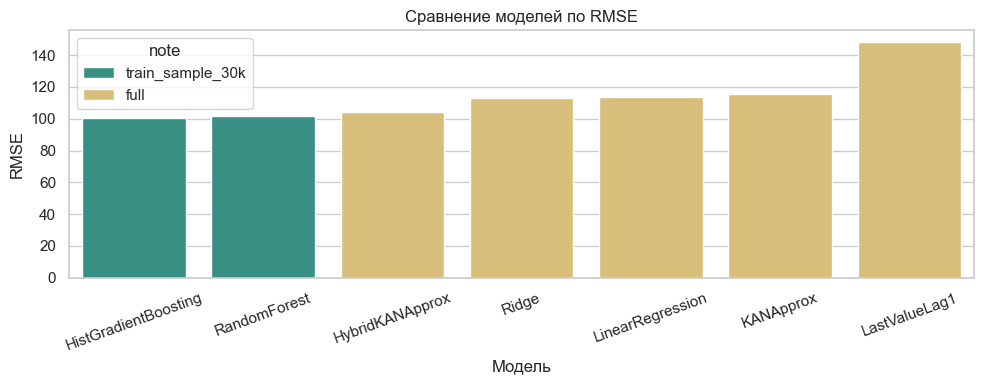

In [19]:
plt.figure(figsize=(10, 4))
sns.barplot(data=metrics_ext, x='model', y='RMSE', hue='note', dodge=False, palette=['#2a9d8f', '#e9c46a'])
plt.title('Сравнение моделей по RMSE')
plt.xlabel('Модель')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Промежуточный вывод

- Лучшие результаты в расширенном сравнении дали `HistGradientBoosting` и `RandomForest`, но они обучались на облегчённой выборке `30k`.
- Среди моделей, рассчитанных на полном наборе признаков и без subsampling, лучший результат дал `HybridKANApprox`.
- Это позволяет отделить две мысли: для практической точности деревья остаются очень сильным baseline, но среди более интерпретируемых и устойчивых full-data моделей гибридный `KAN` выглядит наиболее интересным.

## Абляция признаков

In [20]:
ablation_path = OUT_DIR / 'russian_electricity_ablation.csv'
if ablation_path.exists():
    ablation_df = pd.read_csv(ablation_path)
else:
    y_train = train['purchase_price_rub_mwh'].astype(float).values
    y_val = val['purchase_price_rub_mwh'].astype(float).values
    y_test = test['purchase_price_rub_mwh'].astype(float).values
    rows = []
    for fs_name, features in feature_sets.items():
        X_train_num, X_val_num, X_test_num, X_train_cat, X_val_cat, X_test_cat, X_train, X_val, X_test = prepare_matrices(features)
        stacked_X = np.vstack([X_train, X_val])
        stacked_y = np.hstack([y_train, y_val])
        stacked_num = np.vstack([X_train_num, X_val_num])
        stacked_cat = np.vstack([X_train_cat, X_val_cat])
        rows.append({'feature_set': fs_name, 'model': 'LinearRegression', **metric_row('LinearRegression', y_test, LinearRegression().fit(stacked_X, stacked_y).predict(X_test), '')})
        rows.append({'feature_set': fs_name, 'model': 'HybridKANApprox', **metric_row('HybridKANApprox', y_test, AdditiveKANRegressor(num_basis=8, alpha=2.0, include_linear=True).fit(stacked_num, stacked_cat, stacked_y).predict(X_test_num, X_test_cat), '')})
    ablation_df = pd.DataFrame(rows)
    ablation_df.to_csv(ablation_path, index=False)

ablation_df.sort_values(['model', 'RMSE'])

,feature_set,model,RMSE,MAE,R2
0,full,HybridKANApprox,104.080471,61.162756,0.940794
1,lags_calendar_flows,HybridKANApprox,105.931846,61.443829,0.938669
2,lags_calendar,HybridKANApprox,105.984480,61.443279,0.938608
3,lags_only,HybridKANApprox,126.404029,79.203456,0.912672
4,full,LinearRegression,113.384523,70.118030,0.929735
5,lags_calendar_flows,LinearRegression,116.845050,73.385709,0.925381
6,lags_calendar,LinearRegression,116.897165,73.504508,0.925314
7,lags_only,LinearRegression,128.687987,80.586416,0.909488


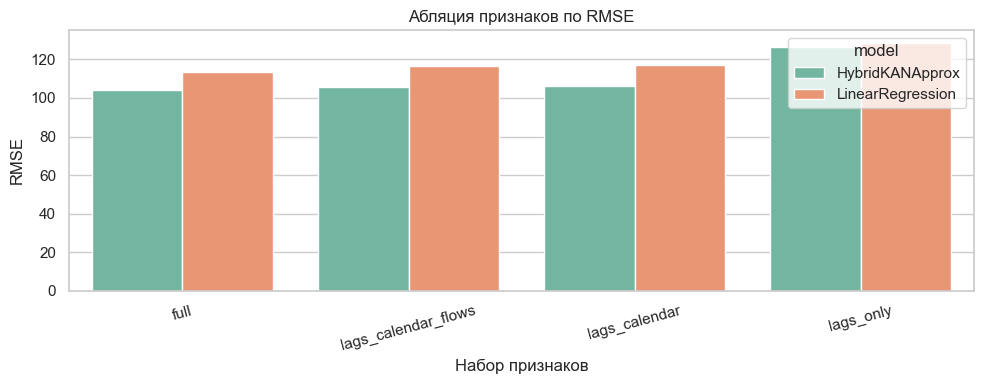

In [21]:
plt.figure(figsize=(10, 4))
sns.barplot(data=ablation_df, x='feature_set', y='RMSE', hue='model', palette='Set2')
plt.title('Абляция признаков по RMSE')
plt.xlabel('Набор признаков')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Что показала абляция

- Переход от `lags_only` к `lags_calendar` даёт заметный выигрыш, значит календарная структура действительно важна.
- Добавление `flows` и суточных потерь ещё немного улучшает результат.
- Лучшее качество достигается на полном наборе признаков, то есть месячные стоимостные факторы и энергетические агрегаты полезны.
- Во всех вариантах `HybridKANApprox` лучше `LinearRegression`, особенно на богатых наборах признаков.

## Диагностика ошибок лучшей полной KAN-модели

In [22]:
pred_path = OUT_DIR / 'russian_electricity_hybridkan_predictions.csv'
err_hour_path = OUT_DIR / 'russian_electricity_error_by_hour.csv'
err_region_path = OUT_DIR / 'russian_electricity_error_by_region.csv'

if pred_path.exists() and err_hour_path.exists() and err_region_path.exists():
    pred_df = pd.read_csv(pred_path, parse_dates=['datetime'])
    err_by_hour = pd.read_csv(err_hour_path)
    err_by_region = pd.read_csv(err_region_path)
else:
    y_train = train['purchase_price_rub_mwh'].astype(float).values
    y_val = val['purchase_price_rub_mwh'].astype(float).values
    X_train_num, X_val_num, X_test_num, X_train_cat, X_val_cat, X_test_cat, X_train, X_val, X_test = prepare_matrices(feature_sets['full'])
    stacked_num = np.vstack([X_train_num, X_val_num])
    stacked_cat = np.vstack([X_train_cat, X_val_cat])
    stacked_y = np.hstack([y_train, y_val])
    model = AdditiveKANRegressor(num_basis=8, alpha=2.0, include_linear=True).fit(stacked_num, stacked_cat, stacked_y)
    pred = model.predict(X_test_num, X_test_cat)
    pred_df = test[['datetime', 'region', 'hour', 'purchase_price_rub_mwh']].copy()
    pred_df['prediction'] = pred
    pred_df['abs_error'] = (pred_df['purchase_price_rub_mwh'] - pred_df['prediction']).abs()
    pred_df['squared_error'] = (pred_df['purchase_price_rub_mwh'] - pred_df['prediction']) ** 2
    pred_df.to_csv(pred_path, index=False)
    err_by_hour = pred_df.groupby('hour').agg(MAE=('abs_error', 'mean'), RMSE=('squared_error', lambda s: float(np.sqrt(s.mean())))).reset_index()
    err_by_region = pred_df.groupby('region').agg(MAE=('abs_error', 'mean'), RMSE=('squared_error', lambda s: float(np.sqrt(s.mean()))), mean_price=('purchase_price_rub_mwh', 'mean')).reset_index().sort_values('RMSE', ascending=False)
    err_by_hour.to_csv(err_hour_path, index=False)
    err_by_region.to_csv(err_region_path, index=False)

err_by_hour.head(), err_by_region.head(10)

(   hour         MAE        RMSE
 0     0  125.744675  197.219649
 1     1   78.542621  128.740841
 2     2   92.745849  153.554577
 3     3   61.242980  110.606632
 4     4   70.743549  138.202038,
                   region         MAE        RMSE   mean_price
 0    Республика Дагестан  132.454221  222.793060  2172.376720
 1   Чеченская Республика  117.253565  198.661621  2085.044328
 2   Республика Ингушетия  106.388458  182.497822  1959.654839
 3  Ставропольский край   92.562060  156.171692  1807.628333
 4        Республика Крым   93.188712  148.056283  1983.318723
 5    Республика Калмыкия   81.553916  142.874129  1694.830376
 6   Новгородская область   57.415784  105.752993  1468.636855
 7    Саратовская область   48.541709  103.422825  1503.993616
 8       Тульская область   62.472449  100.528978  1783.166720
 9      Республика Алтай   66.265105   99.223392  1404.461964)

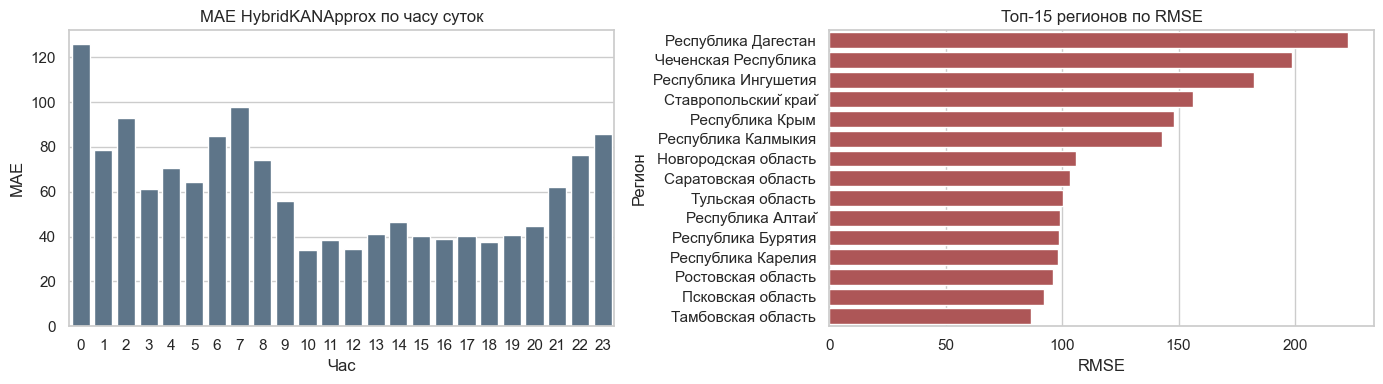

In [23]:
img1 = OUT_DIR / 'hybridkan_mae_by_hour.png'
img2 = OUT_DIR / 'hybridkan_top_region_rmse.png'
img3 = OUT_DIR / 'hybridkan_actual_vs_pred_sample.png'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=err_by_hour, x='hour', y='MAE', color='#577590', ax=axes[0])
axes[0].set_title('MAE HybridKANApprox по часу суток')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('MAE')

sns.barplot(data=err_by_region.head(15), y='region', x='RMSE', color='#bc4749', ax=axes[1])
axes[1].set_title('Топ-15 регионов по RMSE')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Регион')

plt.tight_layout()
plt.show()

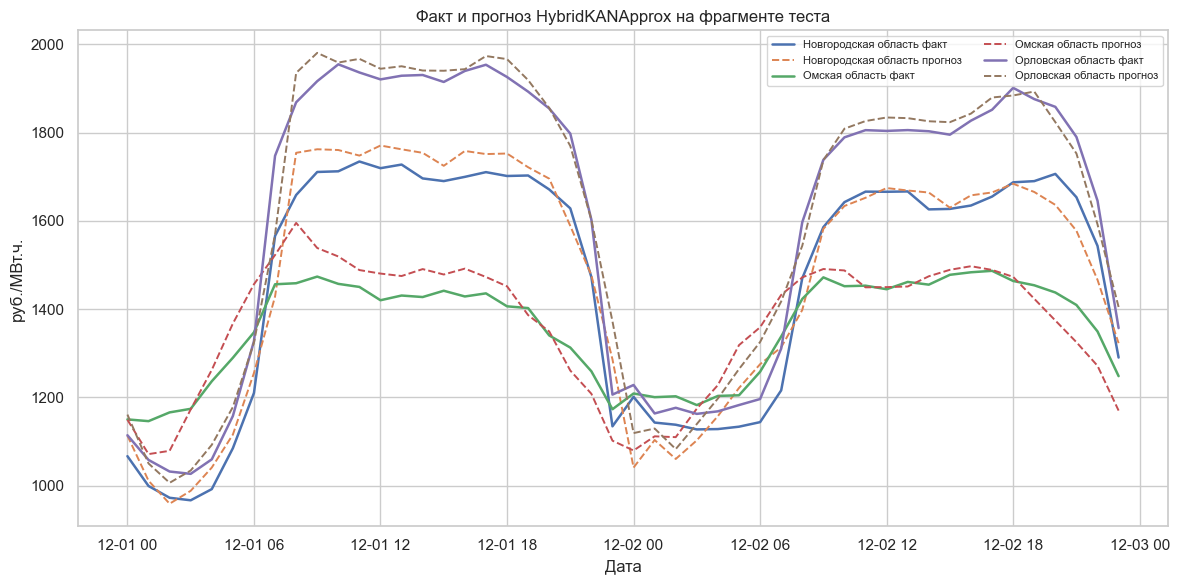

In [24]:
regions = list(pred_df['region'].drop_duplicates()[:3])
vis = pred_df[pred_df['region'].isin(regions)].sort_values(['region', 'datetime']).groupby('region').head(48)
plt.figure(figsize=(12, 6))
for region, sub in vis.groupby('region'):
    plt.plot(sub['datetime'].to_numpy(), sub['purchase_price_rub_mwh'].to_numpy(), label=f'{region} факт', linewidth=1.8)
    plt.plot(sub['datetime'].to_numpy(), sub['prediction'].to_numpy(), linestyle='--', label=f'{region} прогноз', linewidth=1.4)
plt.title('Факт и прогноз HybridKANApprox на фрагменте теста')
plt.xlabel('Дата')
plt.ylabel('руб./МВт.ч.')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### Интерпретация диагностики

- Ошибка модели меняется по часу суток, что подтверждает неодинаковую сложность прогнозирования в разные часы нагрузки.
- Наибольшие ошибки наблюдаются в ряде южных регионов, где средний уровень цены выше и динамика менее стабильна.
- Даже там модель сохраняет адекватную форму прогноза, но хуже ловит амплитуду резких колебаний.

## Текстовые выводы для ВКР

### Короткая интерпретация результатов

1. Данные электроэнергии РФ подходят для задачи краткосрочного прогнозирования цены, поскольку содержат выраженную временную структуру, региональную неоднородность и набор факторов, потенциально связанных с нелинейной динамикой цены.
2. По EDA установлено, что цена обладает сильной инерционностью: корреляция с лагом `1` час составляет около `0.94`, а с лагом `24` часа около `0.85`. Также выявлена выраженная внутрисуточная сезонность.
3. В расширенном сравнении моделей лучшие значения метрик дали `HistGradientBoosting` и `RandomForest`, однако эти модели обучались на сокращённой выборке для ускорения расчётов. Среди моделей, обученных на полном наборе данных, лучший результат показала `HybridKANApprox`.
4. Чистая `KANApprox` уступила гибридной версии, что поддерживает гипотезу о большей практической эффективности гибридных архитектур с `KAN`-блоком по сравнению с изолированным использованием `KAN`.
5. Абляционное исследование показало, что наибольший вклад дают лаговые признаки, однако добавление календарных факторов, перетоков, суточных потерь и месячных стоимостных показателей последовательно улучшает качество прогноза.
6. Таким образом, для рассматриваемой задачи `KAN` целесообразно использовать именно в гибридной архитектуре, где линейная часть описывает базовую структуру зависимости, а нелинейный `KAN`-блок моделирует более сложные эффекты.

### Методические ограничения

- Окно пересечения почасовых, суточных и месячных данных ограничено периодом с конца августа по конец декабря 2023 года.
- Для tree-based моделей использовалась облегчённая обучающая выборка `30k`, чтобы сохранить воспроизводимость и разумное время работы ноутбука.
- `KANApprox` и `HybridKANApprox` в ноутбуке представлены устойчивой аддитивной аппроксимацией на базисных функциях, которая отражает идею `KAN`, но не является полной spline-реализацией исходной архитектуры.